   valence  year  acousticness  \
0   0.0594  1921         0.982   
1   0.9630  1921         0.732   

                                             artists  danceability  \
0  ['Sergei Rachmaninoff', 'James Levine', 'Berli...         0.279   
1                                     ['Dennis Day']         0.819   

   duration_ms  energy  explicit                      id  instrumentalness  \
0       831667   0.211         0  4BJqT0PrAfrxzMOxytFOIz             0.878   
1       180533   0.341         0  7xPhfUan2yNtyFG0cUWkt8             0.000   

   key  liveness  loudness  mode  \
0   10     0.665   -20.096     1   
1    7     0.160   -12.441     1   

                                                name  popularity release_date  \
0  Piano Concerto No. 3 in D Minor, Op. 30: III. ...           4         1921   
1                            Clancy Lowered the Boom           5         1921   

   speechiness   tempo  
0       0.0366  80.954  
1       0.4150  60.936  
   mode                

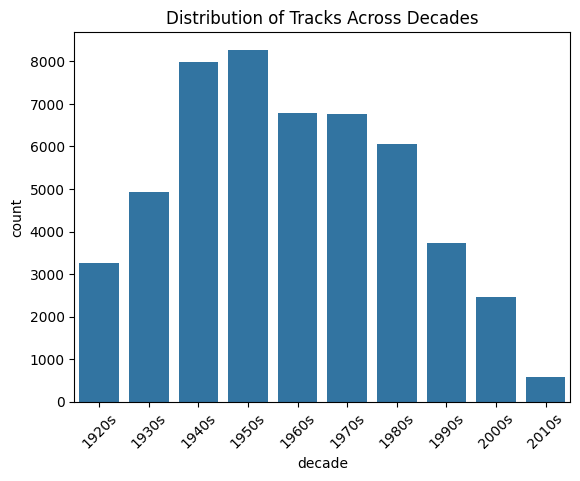

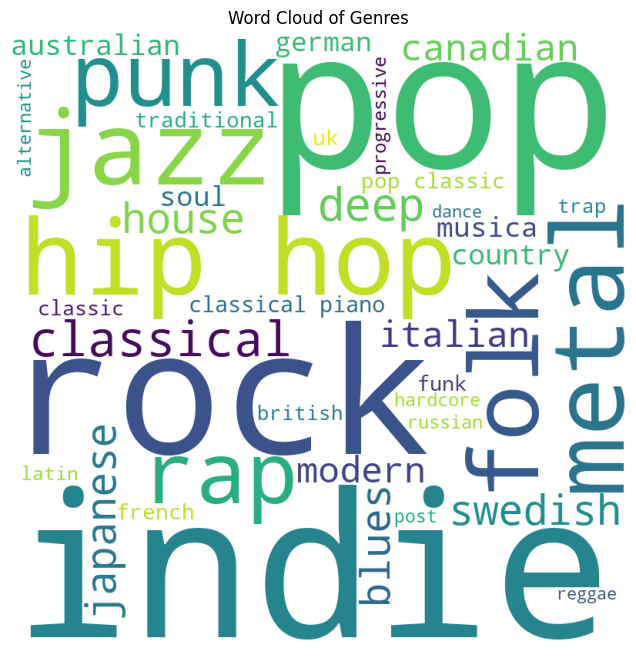

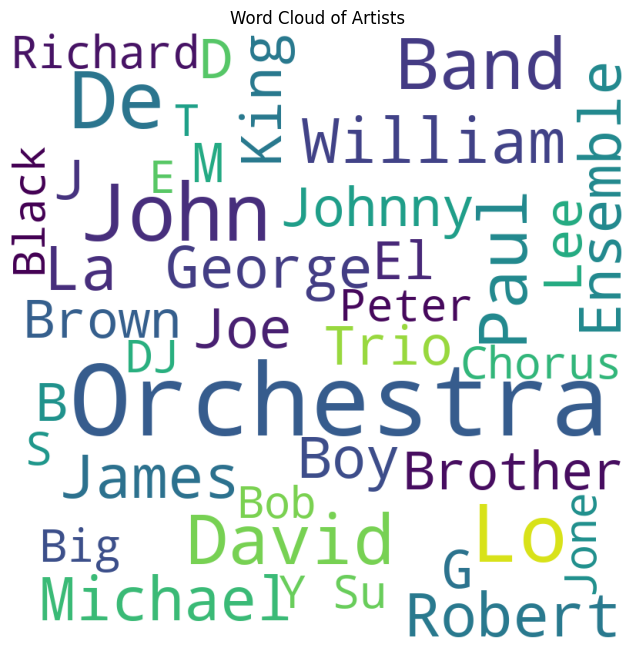

                  artists  count
0    ['Эрнест Хемингуэй']   1211
1   ['Эрих Мария Ремарк']   1068
2    ['Francisco Canaro']    942
3       ['Frank Sinatra']    630
4     ['Ignacio Corsini']    628
5       ['Elvis Presley']    504
6         ['Johnny Cash']    484
7           ['Bob Dylan']    474
8  ['The Rolling Stones']    471
9      ['The Beach Boys']    455


Missing columns in song data for Shape of You: ['danceability', 'energy', 'loudness', 'tempo'], skipping.
Missing columns in song data for Blinding Lights: ['danceability', 'energy', 'loudness', 'tempo'], skipping.
No valid song vectors found, returning a zero vector.
        valence  year  acousticness                        artists  \
93224       0.0   NaN      0.000061               ['Apocolothoth']   
40413       0.0   NaN      0.000047               ['Apocolothoth']   
152535      0.0   NaN      0.503000                      ['Chelo']   
78669       0.0   NaN      0.985000              ['Mohammed Rafi']   
129402      0.0   NaN      0.716000              ['Willie Nelson']   
2764        0.0   NaN      0.936000  ['Orquesta Francisco Canaro']   
8485        0.0   NaN      0.842000            ['Louis Armstrong']   
23582       0.0   NaN      0.983000             ['Master Ebrahim']   
124216      0.0   NaN      0.000001  ['Rain Sounds Factory STHLM']   
38356       0.0   NaN      0.86

In [ ]:
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from wordcloud import WordCloud, STOPWORDS
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
from collections import defaultdict
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
import os
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv("data.csv")
genre_data = pd.read_csv("data_by_genres.csv")
year_data = pd.read_csv("data_by_year.csv")
artist_data = pd.read_csv("data_by_artist.csv")

print(data.head(2))
print(genre_data.head(2))
print(year_data.head(2))
print(artist_data.head(2))

# Info
print(data.info())
print(genre_data.info())

# Create decade column
data['release_date'] = pd.to_datetime(data['release_date'], errors='coerce')
data['year'] = data['release_date'].dt.year
data['decade'] = data['year'].apply(lambda x: str(x)[:3] + '0s' if pd.notnull(x) else None)

# Phase 2: Visualizations
sns.countplot(x='decade', data=data)
plt.title('Distribution of Tracks Across Decades')
plt.xticks(rotation=45)
plt.show()

sound_features = ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'valence']
fig1 = px.line(year_data, x='year', y=sound_features, title='Trend of Various Sound Features Over Decades')
fig1.show()

fig2 = px.line(year_data, x='year', y='loudness', title='Trend of Loudness Over Decades')
fig2.show()

# Top 10 genres by popularity
top10_genres = genre_data.sort_values('popularity', ascending=False).head(10)
fig3 = px.bar(top10_genres, x='genres', y=['valence', 'energy', 'danceability', 'acousticness'],
              barmode='group', title='Trend of Sound Features Over Top 10 Genres')
fig3.show()

# WordCloud for genres
comment_words = ' '.join(genre_data['genres'].dropna())
stopwords = set(STOPWORDS)
wordcloud = WordCloud(width=800, height=800, background_color='white', stopwords=stopwords,
                      max_words=40, min_font_size=10).generate(comment_words)
plt.figure(figsize=(8, 8))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Genres")
plt.show()

# WordCloud for artists
comment_words = ' '.join(artist_data['artists'].dropna())
wordcloud = WordCloud(width=800, height=800, background_color='white', stopwords=stopwords,
                      max_words=40, min_font_size=10).generate(comment_words)
plt.figure(figsize=(8, 8))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Artists")
plt.show()

# Top 10 artists by count
top10_artists = data['artists'].value_counts().reset_index()
top10_artists.columns = ['artists', 'count']
print(top10_artists.head(10))

# Phase 3: Clustering
# Clustering on genre_data
kmeans_genre = KMeans(n_clusters=12, random_state=42)
genre_features = genre_data.select_dtypes(include=[np.number])
genre_data['genre_cluster'] = kmeans_genre.fit_predict(genre_features)

# t-SNE for genre visualization
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
tsne_results = tsne.fit_transform(genre_features)
genre_data['tsne-2d-one'] = tsne_results[:, 0]
genre_data['tsne-2d-two'] = tsne_results[:, 1]
fig4 = px.scatter(genre_data, x='tsne-2d-one', y='tsne-2d-two', color='genre_cluster',
                 hover_data=['genres'], title='t-SNE Clusters of Genres')
fig4.show()

# Fit a K-means clustering model on the song data using 25 clusters
song_features = data.select_dtypes(include=[np.number]).dropna()
kmeans_song = KMeans(n_clusters=25, random_state=42)
cluster_labels = kmeans_song.fit_predict(song_features)

# Safely assign cluster labels only to the rows that were used for clustering
data['song_cluster'] = np.nan  # Initialize column
data.loc[song_features.index, 'song_cluster'] = cluster_labels


# PCA for song visualization
pca = PCA(n_components=2)
song_pca = pca.fit_transform(song_features)

# Assign PCA results only to the subset used for PCA
data['pca-one'] = np.nan
data['pca-two'] = np.nan
data.loc[song_features.index, 'pca-one'] = song_pca[:, 0]
data.loc[song_features.index, 'pca-two'] = song_pca[:, 1]

# Plot
fig5 = px.scatter(
    data.loc[song_features.index],  # only the subset with PCA
    x='pca-one',
    y='pca-two',
    color='song_cluster',
    hover_data=['name'],
    title='PCA Clusters of Songs'
)
fig5.show()

# Phase 4: Recommendation System
client_id = '55e14d4aa5964858abd260d7d6a60cde'
client_secret = '71323275bf5349088a7e156154687b0c'

sp = spotipy.Spotify(auth_manager=SpotifyClientCredentials(
    client_id=client_id,
    client_secret=client_secret
))


def find_song(name, year):
    result = sp.search(q=f"track:{name} year:{year}", limit=1)
    tracks = result['tracks']['items']
    if tracks:
        return tracks[0]
    return None


def get_song_data(song, dataset):
   
    results = dataset[
        (dataset['name'].str.lower() == song['name'].lower()) &
        (dataset['year'] == song['year'])
    ]
    
    if not results.empty:
        return results.iloc[0]
    else:
       
        try:
            return find_song(song['name'], song['year'])
        except Exception as e:
            print(f"Failed to find song '{song['name']}' ({song['year']}): {e}")
            return None



def get_mean_vector(song_list, dataset):
    song_vectors = []
    required_columns = ['danceability', 'energy', 'loudness', 'tempo']  # Define required columns explicitly

    for song in song_list:
        song_data = get_song_data(song, dataset)
        if song_data is None:
            continue
        
        missing_columns = [col for col in required_columns if col not in song_data]
        if missing_columns:
            print(f"Missing columns in song data for {song['name']}: {missing_columns}, skipping.")
            continue
       
        song_vector = [song_data[col] for col in required_columns]
        song_vectors.append(song_vector)
    
    if song_vectors:
        mean_vector = np.mean(song_vectors, axis=0)
    else:
        print("No valid song vectors found, returning a zero vector.")
        mean_vector = np.zeros(len(required_columns)) 
    
    if np.isnan(mean_vector).any():
        print("Warning: mean_vector contains NaN values. Skipping this song.")
        return np.zeros_like(mean_vector) 
    
    return mean_vector

def flatten_dict_list(dict_list):
    flattened_dict = defaultdict(list)
    for dictionary in dict_list:
        for key, value in dictionary.items():
            flattened_dict[key].append(value)
    return flattened_dict

def recommend_songs(song_list, dataset, n_songs=10):
    required_columns = ['danceability', 'energy', 'loudness', 'tempo']  # Example columns for scaling

    if not all(col in dataset.columns for col in required_columns):
        print(f"Missing some columns in dataset, skipping scaling.")
        return []

    scaler = StandardScaler()
    song_features = dataset[required_columns]  
    scaled_data = scaler.fit_transform(song_features)

    song_center = get_mean_vector(song_list, dataset)

    scaled_center = scaler.transform([song_center]) 

    distances = np.linalg.norm(scaled_data - scaled_center, axis=1)
    indices = distances.argsort()[:n_songs]

    recommended_songs = dataset.iloc[indices]
    return recommended_songs




# Test the recommender
example_songs = [
    {'name': 'Shape of You', 'year': 2017},
    {'name': 'Blinding Lights', 'year': 2019}
]

recommended = recommend_songs(example_songs, data)
print(recommended)
